<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Convolutional_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Denoising using Convolutional Autoencoder**

## 📌 Model Used
In this project, a **Convolutional Autoencoder (CAE)** is used to remove salt-and-pepper noise from images.  
The model learns to convert noisy images into clean images using supervised learning.

## 📂 Dataset Used
Dataset: **Salt and Pepper Noise Images Dataset ([Kaggle Link](https://www.kaggle.com/datasets/rajneesh231/salt-and-pepper-noise-images?select=Ground_truth))**  

The dataset contains:
- `Noisy_folder` → Images with salt-and-pepper noise  
- `Ground_truth` → Corresponding clean images  

Each noisy image has a matching clean image used for training the model.

# **1. Importing all the required libraries**

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import backend as k

%matplotlib inline

from keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Reshape

from keras import regularizers
from keras.regularizers import l2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import BatchNormalization, Conv2DTranspose

import cv2
import os
import kagglehub

# **2. Downloading Dataset**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("rajneesh231/salt-and-pepper-noise-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salt-and-pepper-noise-images' dataset.
Path to dataset files: /kaggle/input/salt-and-pepper-noise-images


# **3. Image Size and Folder Setup**

**What is `IMG_SIZE = 128`?**

- Defines the height and width of the images used for training  
- All images are resized to **128 × 128 pixels**  
- Ensures fixed-size input for the neural network  

**Why 128 is chosen?**
- Preserves image details  
- Reduces pixelation  
- Helps the model learn better spatial features  
- Keeps computation balanced (not too heavy like 256×256)

**What are `noisy_dir` and `clean_dir`**

- `noisy_dir` → Path to folder containing noisy images  
- `clean_dir` → Path to folder containing original clean images  

`os.path.join()`:
- Combines the main dataset path with folder names  
- Ensures correct directory structure on any operating system  

**Purpose of This Step**

- Sets the image resolution  
- Locates dataset folders  
- Prepares data paths for loading and training the convolutional autoencoder

In [ ]:
IMG_SIZE = 128

noisy_dir = os.path.join(path, "Noisy_folder")
clean_dir = os.path.join(path, "Ground_truth")

# **4. Loading and Preprocessing Images**
- Two empty lists are created to store noisy and clean images.
- The loop goes through each file in the noisy image folder.
- For every noisy image, it finds the corresponding clean image.
- `cv2.imread()` loads the images from disk.
- `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` converts images from OpenCV’s BGR format to RGB for correct color representation.
- `cv2.resize()` resizes all images to the defined `IMG_SIZE` (128 × 128) so the model receives fixed-size input.
- Images are added in pairs: noisy image → clean image.
- The lists are converted into NumPy arrays for deep learning.
- Pixel values are normalized from 0–255 to 0–1 to improve training stability.
- The dataset shape is printed to confirm correct loading (expected: number_of_images, 128, 128, 3).

In [ ]:
noisy_images = []
clean_images = []

for filename in os.listdir(noisy_dir):

    noisy_path = os.path.join(noisy_dir, filename)
    clean_filename = filename.replace("noisy_", "")
    clean_path = os.path.join(clean_dir, clean_filename)

    if os.path.exists(clean_path):

        noisy_img = cv2.imread(noisy_path)
        noisy_img = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB)

        clean_img = cv2.imread(clean_path)
        clean_img = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)

        noisy_img = cv2.resize(noisy_img, (IMG_SIZE, IMG_SIZE))
        clean_img = cv2.resize(clean_img, (IMG_SIZE, IMG_SIZE))

        noisy_images.append(noisy_img)
        clean_images.append(clean_img)

noisy_images = np.array(noisy_images).astype('float32') / 255.
clean_images = np.array(clean_images).astype('float32') / 255.

print("Dataset shape:", noisy_images.shape)

Dataset shape: (300, 128, 128, 3)


# **5. Train-Test Split**
- `train_test_split` divides the dataset into training and testing sets.  
- `noisy_images` are used as input and `clean_images` as target output.  
- `test_size = 0.2` means:
  - 80% data used for training  
  - 20% data used for testing  
- `random_state = 42` ensures the same split every time for reproducibility.  
- `x_train, y_train` → used to train the model  
- `x_test, y_test` → used to evaluate model performance  
- Shapes are printed to confirm correct data splitting.

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    noisy_images,
    clean_images,
    test_size=0.2,
    random_state=42
)

print(x_train.shape, x_test.shape)

(240, 128, 128, 3) (60, 128, 128, 3)


# **6. Convolutional Autoencoder Model**
- `Input(shape=(IMG_SIZE, IMG_SIZE, 3))` defines the input image size (128 × 128 with 3 RGB channels).

### Encoder
- `Conv2D` layers extract image features like edges and textures.
- `BatchNormalization` stabilizes learning and improves performance.
- `MaxPooling2D` reduces image size while keeping important features.

### Bottleneck
- `Conv2D(256)` stores compressed information of the image.
- This acts as the central representation used for reconstruction.

### Decoder
- `Conv2DTranspose` increases the image size and learns how to reconstruct details.
- Helps produce sharper outputs compared to simple upsampling.
- `BatchNormalization` improves training stability.

### Output Layer
- Final `Conv2D` reconstructs the clean RGB image.
- `sigmoid` keeps pixel values between 0 and 1.

### Loss Function
- `combined_loss` uses:
  - MAE → reduces pixel differences
  - SSIM → preserves structure and visual similarity

### Model Compilation
- `optimizer='adam'` is used for efficient learning.
- Model is trained to convert noisy images into clean reconstructed images.

### Summary
- Displays model layers, output shapes, and total parameters.
- Confirms encoder–decoder autoencoder architecture.

In [ ]:
input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(128, (3,3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(64, (3,3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

def combined_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mae + ssim

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss=combined_loss)

autoencoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743,939 (2.84 MB)

 Trainable params: 742,659 (2.83 MB)

 Non-trainable params: 1,280 (5.00 KB)

# **7. Model Training**

- `autoencoder.fit()` is used to train the model.  
- `x_train` → noisy images used as input.  
- `y_train` → clean images used as target output.  
- `epochs=150` means the model will learn from the dataset 100 times.  
- `batch_size=16` means 16 images are processed at a time during training.  
- `validation_data=(x_test, y_test)` is used to check model performance on unseen data.  
- The training progress (loss and validation loss) is stored in `history` for analysis and plotting.

In [ ]:
history = autoencoder.fit(
    x_train,
    y_train,
    epochs=120,
    batch_size=16,
    validation_data=(x_test, y_test)
)

Epoch 1/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 0.9610 - val_loss: 0.9119
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.5439 - val_loss: 0.8844
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4889 - val_loss: 0.9110
Epoch 4/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4538 - val_loss: 0.9096
Epoch 5/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4364 - val_loss: 0.9100
Epoch 6/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4410 - val_loss: 0.9108
Epoch 7/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.4218 - val_loss: 0.9039
Epoch 8/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.4167 - val_loss: 0.9106
Epoch 9/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.4181 - val_loss: 0.8979
Epoch 10/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.3953 - val_loss: 0.8903
Epoch 11/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.3875 - val_loss: 0.8858
Epoch 12/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/st

# **8. Plotting Training and Validation Loss**
- `history.history.keys()` shows the metrics stored during training (such as loss and val_loss).  
- `history.history['loss']` represents training loss for each epoch.  
- `history.history['val_loss']` represents validation loss for each epoch.  
- `plt.plot()` is used to draw the loss curves.  
- `plt.title()` sets the graph title.  
- `plt.ylabel('Loss')` labels the vertical axis.  
- `plt.xlabel('Epoch')` labels the horizontal axis.  
- `plt.legend()` differentiates training and validation curves.  
- `plt.show()` displays the final graph.

This graph helps analyze model performance and check for overfitting or underfitting.

dict_keys(['loss', 'val_loss'])


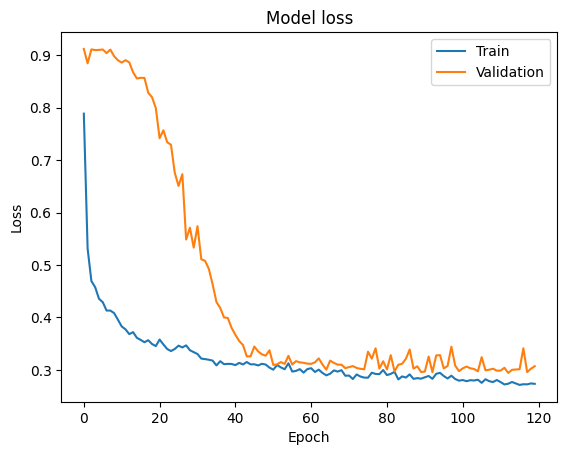

In [ ]:
print(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

# **9. Prediction**
- `autoencoder.predict()` is used to generate output images from the trained model.  
- `x_test` contains noisy images given as input to the model.  
- The model processes these images and produces reconstructed (denoised) images.  
- The output is stored in `decoded_imgs`.  
- These images will be compared with the original clean images to evaluate model performance.

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


# **10. Image Comparison**
- `n = 10` selects 10 sample images for visualization.  
- `plt.figure(figsize=(15,6))` sets the display size of the plot.  
- A loop is used to display images in three rows.  

Row 1 → Noisy input images  
Row 2 → Denoised images predicted by the model  
Row 3 → Original clean images (ground truth)  

- `plt.imshow()` displays the images.  
- `plt.title()` labels each image type.  
- `plt.axis("off")` removes axis for better visualization.  
- `plt.show()` displays the final comparison plot.

This helps visually evaluate how well the model removes noise and reconstructs clean images.



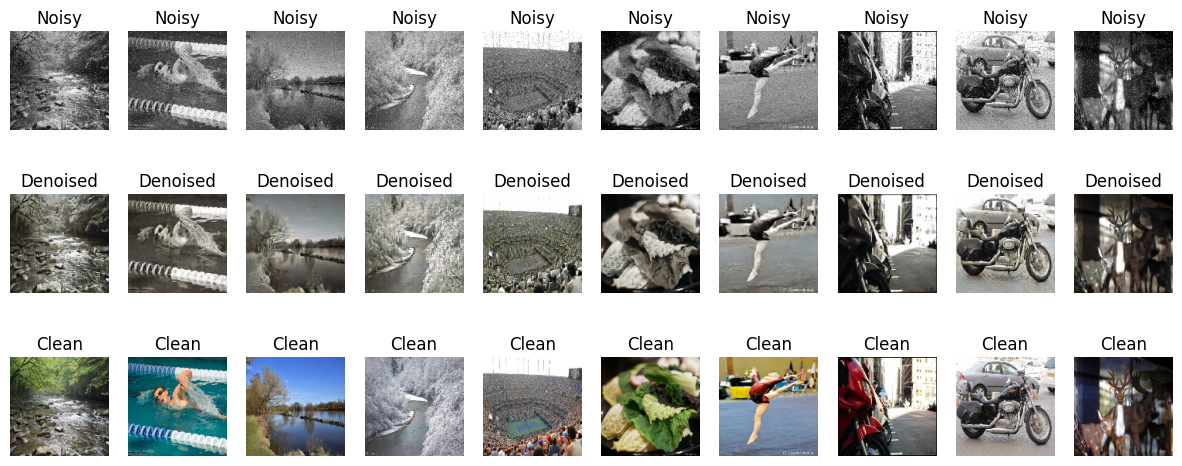

In [ ]:
n = 10
plt.figure(figsize=(15,6))

for i in range(n):

    # Noisy
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i])
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis("off")

    # Ground Truth
    ax = plt.subplot(3,n,i+1+2*n)
    plt.imshow(y_test[i])
    plt.title("Clean")
    plt.axis("off")

plt.show()